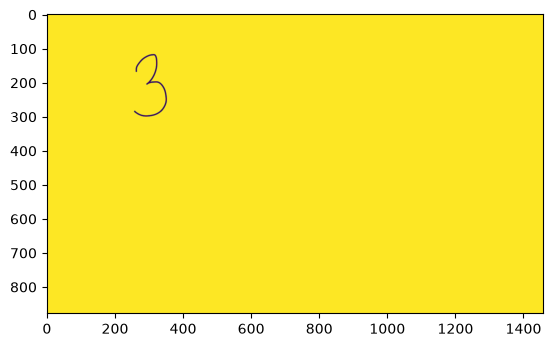

Arr is: 
[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 2

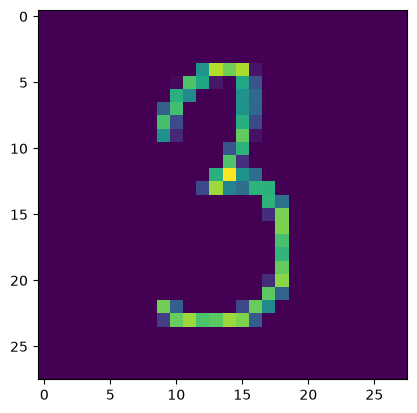

In [ ]:
# load an image and try centercrop
import torch
from PIL import Image
from matplotlib import pyplot
import numpy as np
from torchvision.transforms import functional as F
from torchvision import transforms as TR

# np.set_printoptions(linewidth=200)
# torch.set_printoptions(linewidth=200)

np.set_printoptions(threshold=np.inf)

img = Image.open(fp="test1.png")
img = img.convert("L")
pyplot.imshow(X=img)
pyplot.show()

arr = np.array(img)

# check if image has a white background. If yes, invert it
if arr.mean() > 127:
    img = Image.eval(img, lambda x: 255 - x) # inversion happens with 255 - x
    arr = np.array(img)

# 1. Threshold to find "digit" pixels vs background
threshold = 50
mask = arr > threshold

# 2. Find bounding box of the digit
coords = np.argwhere(mask)
y0, x0 = coords.min(axis=0)
y1, x1 = coords.max(axis=0) + 1

# 3. Crop to that bounding box
digit = arr[y0:y1, x0:x1]
# print(digit)

# 4. Resize so the longest side is 20px, preserving aspect ratio
digit_img = Image.fromarray(digit)
h, w = digit.shape
scale = 20 / max(h, w)
new_h, new_w = max(1, int(h * scale)), max(1, int(w * scale))
digit_img = digit_img.resize((new_w, new_h))

# 5. Paste onto a 28x28 black canvas, centered
canvas = Image.new("L", (28, 28), color=0)
paste_x = (28 - new_w) // 2
paste_y = (28 - new_h) // 2
canvas.paste(digit_img, (paste_x, paste_y))

img = canvas  # this replaces img before it goes into `transform`

pyplot.imshow(X=img)
pyplot.show()
